In [1]:
import os, sys
from pathlib import Path
try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception:
    pass
sys.path.insert(0, 'utils')
print('cwd:', os.getcwd())

cwd: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [3]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, roc_auc_score,
                              recall_score, precision_score, confusion_matrix)
import config

pd.set_option('display.float_format', '{:,.0f}'.format)

LAB_FOLDER   = Path(config.MULTI_EXP_FOLDER + '_nc_subtract')
TRAIN_JL     = config.TRAINING_DATA_PATH
RESULT_JL    = config.TRAINING_RESULT_PATH

In [30]:
# ── Dataset ───────────────────────────────────────────────────────────────────
FOLDER = 'D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01'          # experiment sub-folder; set to None to scan all

# ── Misclassification section ─────────────────────────────────────────────────
MODEL_KEY      = 'cnn_gru_dual'   # key as in config.MODEL_KEY_MAP / results dict
OUTLIER_FILTER = None             # None = baseline; or e.g. 'lstm_ae_pw_ds1_label_elbow'
N_SPLITS       = 1               # must match the n_splits used during training

# Automatically select the correct results file based on n_splits
RESULT_JL = (config.TRAINING_10FOLD_RESULT_PATH if N_SPLITS > 1
             else config.TRAINING_RESULT_PATH)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
CURVE_ALPHA    = 0.04   # individual curve transparency in grid
MAX_CONC_COLS  = 7      # cap grid columns; concentrations are binned if more
FIG_DPI        = 110

# ── Colour map for targets (consistent across all sections) ──────────────────
# Filled in at load time once we know the unique labels.
TARGET_COLORS  = {}     # {label_str: colour}

In [31]:
def _conc_label(v):
    """Human-readable concentration string: 1_000_000 → '1M', 10_000 → '10K', etc."""
    if v >= 1e6:  return f'{v/1e6:.4g}M'
    if v >= 1e3:  return f'{v/1e3:.4g}K'
    return f'{v:.4g}'


def list_available_folders(lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Return DataFrame of folders that have non-None concentration data."""
    rows = []
    for p in sorted(Path(lab_folder).iterdir()):
        if not p.is_dir(): continue
        jl_path = p / train_jl
        if not jl_path.exists(): continue
        try:
            d = joblib.load(jl_path)
        except Exception:
            continue
        c = d.get('concentration')
        if c is None: continue
        c = np.array(c, dtype=float)
        if np.all(np.isnan(c)): continue
        labels = d['well_labels']
        rows.append({
            'folder': p.name,
            'n_samples': len(labels),
            'n_targets': len(np.unique(labels)),
            'n_conc': len(np.unique(c[~np.isnan(c)])),
            'conc_range': f"{_conc_label(np.nanmin(c))} – {_conc_label(np.nanmax(c))}",
        })
    return pd.DataFrame(rows)


def load_folder_data(folder, lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Load ori_curves, labels, concentration for *folder*.
    
    Returns dict with keys:
        ori_curves    : (N, T) float ndarray
        labels        : (N,)  str ndarray
        concentration : (N,)  float ndarray  (NaN where missing)
        timestamps    : (T,)  float ndarray or None
        folder        : str
    """
    p = Path(lab_folder) / folder / train_jl
    d = joblib.load(p)

    curves_store = d['curves']
    ori = curves_store['ori_curves'] if isinstance(curves_store, dict) else curves_store

    labels = np.array(d['well_labels'])
    raw_conc = d.get('concentration')
    conc = np.array(raw_conc if raw_conc is not None else [np.nan] * len(labels), dtype=float)
    ts     = np.array(d.get('timestamps', None))
    if ts is not None and ts.ndim > 1: ts = ts[0]   # some fmts store per-curve

    kf_list = d.get('kinetic_features')
    kf = kf_list[0].reset_index(drop=True) if kf_list else None  # index 0 = ori_curves features

    return dict(ori_curves=ori, labels=labels, concentration=conc,
                timestamps=ts, kinetic_features=kf, folder=folder)



def _assign_target_colors(labels):
    """Populate global TARGET_COLORS from tab10, stable across plots in a session."""
    global TARGET_COLORS
    unique = sorted(np.unique(labels))
    palette = plt.get_cmap('tab10').colors
    TARGET_COLORS = {lbl: palette[i % 10] for i, lbl in enumerate(unique)}

In [32]:
def load_results(folder, lab_folder=LAB_FOLDER, result_jl=RESULT_JL):
    """Load classification_performances.joblib for *folder*.
    Returns the inner results dict for the first available curve_type key,
    or None if the file does not exist.
    """
    p = Path(lab_folder) / folder / result_jl
    if not p.exists():
        print(f'[!] Results not found: {p}')
        return None
    return joblib.load(p)


def _get_res_entry(all_results, outlier_filter=None):
    """Navigate the nested results dict to the per-filter entry.
    
    Structure: all_results[curve_type_key][mode_key][outlier_filter]
    Returns (res_entry, curve_type_key, mode_key) or (None, None, None).
    """
    for ct_key, ct_val in all_results.items():
        if not isinstance(ct_val, dict): continue
        for mode_key, mode_val in ct_val.items():
            if not isinstance(mode_val, dict): continue
            if outlier_filter in mode_val:
                return mode_val[outlier_filter], ct_key, mode_key
    return None, None, None


def _reconstruct_fold_conc(labels, concentration, n_splits=N_SPLITS, outlier_filter=None, features_df=None):
    """Reconstruct test-fold sample indices using the same StratifiedKFold used during training.
    
    Returns list of concentration arrays (one per fold), aligned with y_trues_ / y_preds_.
    """
    # Apply outlier filter mask
    if outlier_filter is not None and features_df is not None and outlier_filter in features_df.columns:
        mask = (features_df[outlier_filter] == 1).fillna(False).values
    else:
        mask = np.ones(len(labels), dtype=bool)

    lbl_f = labels[mask]
    con_f = concentration[mask]

    le = LabelEncoder()
    y_enc = le.fit_transform(lbl_f)

    min_class = np.unique(y_enc, return_counts=True)[1].min()
    actual_splits = min(n_splits, min_class)

    splitter = StratifiedKFold(n_splits=actual_splits, shuffle=True, random_state=0)
    fold_concs = []
    fold_labels = []
    for _, test_idx in splitter.split(np.zeros(len(y_enc)), y_enc):
        fold_concs.append(con_f[test_idx])
        fold_labels.append(le.inverse_transform(y_enc[test_idx]))
    return fold_concs, fold_labels, le


def build_prediction_df(res_entry, model_key, fold_concs, fold_labels, le):
    """Concatenate per-fold predictions into a single DataFrame with concentration.
    Columns: true_label, pred_label, concentration, correct.
    """
    pred_key = f'y_preds_{model_key}_'
    if pred_key not in res_entry:
        # Try config lookup
        for pk, _, _ in [config.MODEL_KEY_MAP.get(model_key, (None,)*3)]:
            if pk and pk in res_entry:
                pred_key = pk
                break
        else:
            print(f'[!] Key {pred_key!r} not found in results. Available: {[k for k in res_entry if "preds" in k][:6]}')
            return None

    rows = []
    n_folds = min(len(res_entry['y_trues_']), len(fold_concs))
    for fi in range(n_folds):
        y_true = res_entry['y_trues_'][fi]
        y_pred = res_entry[pred_key][fi]
        conc_f = fold_concs[fi]
        lbl_f  = fold_labels[fi]

        # Decode integer labels → strings if needed
        if isinstance(y_true[0], (int, np.integer)):
            true_strs = le.inverse_transform(y_true)
            pred_strs = le.inverse_transform(y_pred)
        else:
            true_strs, pred_strs = np.array(y_true), np.array(y_pred)

        for j in range(min(len(true_strs), len(conc_f))):
            rows.append(dict(
                true_label=true_strs[j],
                pred_label=pred_strs[j],
                concentration=conc_f[j],
                correct=(true_strs[j] == pred_strs[j]),
                fold=fi,
            ))
    return pd.DataFrame(rows)


def plot_misclassification_by_concentration(
        pred_df, title='', model_key=''):
    """Two panels:
    Left  — accuracy per target × concentration (line plot).
    Right — confusion matrix where rows = (target, conc) and cols = predicted target.
    """
    if pred_df is None or pred_df.empty:
        print('[!] No prediction data available.'); return

    valid = pred_df[~np.isnan(pred_df['concentration'])].copy()
    valid['conc_label'] = valid['concentration'].map(_conc_label)
    unique_tgt  = sorted(valid['true_label'].unique())
    unique_conc = sorted(valid['concentration'].unique())
    conc_lbls   = [_conc_label(c) for c in unique_conc]

    # ── Panel 1: accuracy per target × concentration ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    for tgt in unique_tgt:
        accs = []
        for c in unique_conc:
            sub = valid[(valid['true_label'] == tgt) & (valid['concentration'] == c)]
            accs.append(sub['correct'].mean() if len(sub) > 0 else np.nan)
        color = TARGET_COLORS.get(tgt, 'gray')
        ax.plot(conc_lbls, accs, marker='o', color=color, label=tgt, linewidth=1.5)

    ax.set_xlabel('Concentration')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('Accuracy per target × concentration')
    ax.legend(fontsize=8, title='Target')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.axhline(1 / len(unique_tgt), color='gray', linestyle='--', linewidth=0.8, label='Chance')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel 2: extended confusion matrix ────────────────────────────────────
    ax = axes[1]
    row_labels = [(tgt, _conc_label(c)) for tgt in unique_tgt for c in unique_conc]
    col_labels = unique_tgt

    mat = np.zeros((len(row_labels), len(col_labels)))
    for ri, (tgt, clbl) in enumerate(row_labels):
        sub = valid[(valid['true_label'] == tgt) & (valid['conc_label'] == clbl)]
        if len(sub) == 0: continue
        for ci, pred_tgt in enumerate(col_labels):
            mat[ri, ci] = (sub['pred_label'] == pred_tgt).sum() / len(sub)

    im = ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Fraction')

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels([f'{t} / {c}' for t, c in row_labels], fontsize=6)
    ax.set_xlabel('Predicted target')
    ax.set_ylabel('True (target / concentration)')
    ax.set_title('Confusion: true(target,conc) → predicted target')

    # Diagonal markers for correct cells
    for ri, (tgt, _) in enumerate(row_labels):
        if tgt in col_labels:
            ci = col_labels.index(tgt)
            ax.add_patch(plt.Rectangle((ci - 0.5, ri - 0.5), 1, 1,
                                        fill=False, edgecolor='black', lw=0.8))

    fig.suptitle(f'{title} — {model_key} misclassification by concentration', fontsize=11)
    plt.tight_layout()
    plt.show()

In [33]:
from IPython.display import display


In [34]:
from IPython.display import display

_DEFAULT_MODELS = ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']

_MODEL_LABELS = {
    'cnn':            'CNN',
    'lstm':           'LSTM',
    'gru':            'GRU',
    'rnn':            'RNN',
    'transformer':    'Transformer',
    'cnn_gru_dual':   'CNN+GRU',
    'cnn_trans_dual': 'CNN+Tr',
    'cnn_lstm_dual':  'CNN+LSTM',
}

# 8-hue palette: ST/MTL pairs, light -> dark with SupCon version
_BAR_PALETTE = [
    ('#b8def5', 'ST'),
    ('#fad7b0', 'MTL'),
    ('#76c1e8', 'ST + SupCon 1'),
    ('#f5ad74', 'MTL + SupCon 1'),
    ('#3498d8', 'ST + SupCon 2'),
    ('#e07c39', 'MTL + SupCon 2'),
    ('#1a6fb5', 'ST + SupCon 3'),
    ('#c05000', 'MTL + SupCon 3'),
]


def plot_stmtl_comparison(res_entry, title='', models=None):
    """8-way grouped bar chart: ST / ST+SC1-3 / MTL / MTL+SC1-3 per model."""
    if res_entry is None:
        print('[!] No results loaded â run Section 5 first.'); return
    if models is None:
        models = _DEFAULT_MODELS

    def _fold_accs(pk):
        return [np.mean(np.array(yt) == np.array(yp)) * 100
                for yt, yp in zip(res_entry.get('y_trues_', []), res_entry.get(pk, []))]

    def _stats(key):
        pk = config.MODEL_KEY_MAP.get(key, (None,))[0]
        if not pk or pk not in res_entry:
            return None, None
        a = _fold_accs(pk)
        return (np.mean(a), np.std(a)) if a else (None, None)

    rows = []
    for base in models:
        label = _MODEL_LABELS.get(base, base)
        st_m, st_s = _stats(base)
        if st_m is None:
            continue
        rows.append(dict(
            name   = label,
            st     = (st_m, st_s),
            sc1    = _stats(base + '_supcon'),
            sc2    = _stats(base + '_supcon2'),
            sc3    = _stats(base + '_supcon3'),
            mtl    = _stats(base + '_mtl'),
            sc1mtl = _stats(base + '_supcon_mtl'),
            sc2mtl = _stats(base + '_supcon2_mtl'),
            sc3mtl = _stats(base + '_supcon3_mtl'),
        ))

    if not rows:
        print('[!] No models found in results.'); return

    _KEYS = ['st', 'mtl', 'sc1', 'sc1mtl', 'sc2', 'sc2mtl', 'sc3', 'sc3mtl']
    n_bars = len(_KEYS)
    n, w = len(rows), 0.10
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(10, n * 3.2), 5.5))

    for ki, ((color, lbl), offset) in enumerate(zip(_BAR_PALETTE, offsets)):
        key = _KEYS[ki]
        xi = np.array([i for i, r in enumerate(rows) if r[key][0] is not None])
        mi = np.array([r[key][0] for r in rows if r[key][0] is not None])
        si = np.array([r[key][1] for r in rows if r[key][0] is not None])
        if not len(xi):
            continue
        bars = ax.bar(xi + offset, mi, w, yerr=si, color=color,
                      label=lbl, capsize=2, error_kw={'linewidth': 0.8, 'alpha': 0.5})
        for bar, mv, sv in zip(bars, mi, si):
            ax.text(bar.get_x() + w / 2, mv + sv + 0.05, f'{mv:.2f}',
                    ha='center', va='bottom', fontsize=6, color='#444', fontweight='bold')

    all_means = [r[k][0] for r in rows for k in _KEYS if r[k][0] is not None]
    ax.set_ylim(max(0, min(all_means) - 3), min(100, max(all_means) + 4))
    ax.set_xticks(x)
    ax.set_xticklabels([r['name'] for r in rows], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=7.5, loc='lower right', ncol=2)
    ax.grid(axis='y', alpha=0.3, linewidth=0.8)
    ax.set_title(f'{title} â ST / MTL × Base / SupCon 1 / SupCon 2 / SupCon 3', fontsize=11)
    plt.tight_layout()
    plt.show()

    def _fmt(m, s): return f'{m:.2f} ± {s:.2f}' if m is not None else 'â'
    df = pd.DataFrame([{
        'Model':       r['name'],
        'ST (%)':      _fmt(*r['st']),
        'ST+SC1 (%)':  _fmt(*r['sc1']),
        'ST+SC2 (%)':  _fmt(*r['sc2']),
        'ST+SC3 (%)':  _fmt(*r['sc3']),
        'MTL (%)':     _fmt(*r['mtl']),
        'MTL+SC1 (%)': _fmt(*r['sc1mtl']),
        'MTL+SC2 (%)': _fmt(*r['sc2mtl']),
        'MTL+SC3 (%)': _fmt(*r['sc3mtl']),
    } for r in rows])
    display(df.set_index('Model'))


In [35]:
_folders = (
    [FOLDER] if FOLDER is not None
    else sorted(f.name for f in Path(LAB_FOLDER).iterdir()
                if f.is_dir() and (f / RESULT_JL).exists())
)
_folders = ['D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01']

---
## Section 9 · RCFD Model Comparison

In [36]:
# ── RCFD section constants & helper ──────────────────────────────────────────

_RCFD_ENCS  = ['cnn', 'gru', 'trans']
_RCFD_DUALS = ['cgd', 'ctd']
_RCFD_DUAL_LABELS   = {'cgd': 'CNN+GRU',   'ctd': 'CNN+Trans'}
_RCFD_ENC_LABELS    = {'cnn': 'CNN', 'gru': 'GRU', 'trans': 'Trans'}
_RCFD_ENC_COLORS    = {'cnn': '#3498d8', 'gru': '#e07c39', 'trans': '#2e8b57'}
_RCFD_SC_VARIANTS   = [('Base', ''), ('SC1', '_supcon_mtl'),
                        ('SC2', '_supcon2_mtl'), ('SC3', '_supcon3_mtl')]
_RCFD_SC_COLORS     = ['#cce5f7', '#76c1e8', '#2a78d6', '#1a4fa0']
_RCFD_DUAL_BASELINE = {'cgd': 'cnn_gru_dual', 'ctd': 'cnn_trans_dual'}


def _rcfd_acc(res, key):
    """Mean ± std fold accuracy for *key*; (None, None) if absent.

    Uses config.MODEL_KEY_MAP for storage-key resolution so that keys with
    non-obvious mappings (e.g. 'cnn' → 'y_preds_AC_', 'trans' variants) are
    handled correctly. Falls back to f'y_preds_AC_{key}_' for RCFD keys and
    any others not in the map.
    """
    pk = config.MODEL_KEY_MAP.get(key, (f'y_preds_AC_{key}_',))[0]
    if pk not in res or 'y_trues_' not in res:
        return None, None
    accs = [np.mean(np.array(yt) == np.array(yp)) * 100
            for yt, yp in zip(res['y_trues_'], res[pk])]
    return (np.mean(accs), np.std(accs)) if accs else (None, None)


def plot_rcfd_overview(res_entry, title=''):
    """9a — Accuracy heat map: all 24 RCFD variants at a glance.

    Rows = SupCon variant (Base / SC1 / SC2 / SC3)
    Cols = encoder × dual backbone  (CNN/CGD  CNN/CTD  GRU/CGD  GRU/CTD  Trans/CGD  Trans/CTD)
    Cell = mean ± std fold accuracy
    """
    col_bases  = [f'{e}_rcfd_{d}' for e in _RCFD_ENCS for d in _RCFD_DUALS]
    col_labels = [f'{_RCFD_ENC_LABELS[e]}/{d.upper()}' for e in _RCFD_ENCS for d in _RCFD_DUALS]
    n_r, n_c   = len(_RCFD_SC_VARIANTS), len(col_bases)

    mat = np.full((n_r, n_c), np.nan)
    std = np.full_like(mat, np.nan)
    for ri, (_, sfx) in enumerate(_RCFD_SC_VARIANTS):
        for ci, base in enumerate(col_bases):
            m, s = _rcfd_acc(res_entry, base + sfx)
            if m is not None:
                mat[ri, ci], std[ri, ci] = m, s

    if np.all(np.isnan(mat)):
        print('[!] No RCFD results found.'); return

    vmin = max(0, np.nanmin(mat) - 2)
    vmax = min(100, np.nanmax(mat) + 1)
    fig, ax = plt.subplots(figsize=(12, 3.8))
    im = ax.imshow(mat, cmap='Blues', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label='Mean acc (%)', fraction=0.018, pad=0.01)

    ax.set_xticks(range(n_c)); ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(n_r))
    ax.set_yticklabels([lbl for lbl, _ in _RCFD_SC_VARIANTS], fontsize=10)

    for xi in range(2, n_c, 2):           # white separator between encoder groups
        ax.axvline(xi - 0.5, color='white', linewidth=2.5)

    for ri in range(n_r):
        for ci in range(n_c):
            if np.isnan(mat[ri, ci]):
                ax.text(ci, ri, '—', ha='center', va='center', fontsize=9, color='#bbb')
            else:
                bright = mat[ri, ci] > (vmin + vmax) * 0.6
                ax.text(ci, ri, f'{mat[ri,ci]:.2f}\n±{std[ri,ci]:.2f}',
                        ha='center', va='center', fontsize=7.5,
                        color='white' if bright else '#222')

    ax.set_title(f'{title} — RCFD: all 24 variants', fontsize=11)
    plt.tight_layout()
    plt.show()

    rows = []
    for ri, (sc_lbl, sfx) in enumerate(_RCFD_SC_VARIANTS):
        row = {'SupCon': sc_lbl}
        for ci, (_, lbl) in enumerate(zip(col_bases, col_labels)):
            m, s = mat[ri, ci], std[ri, ci]
            row[lbl] = f'{m:.2f}±{s:.2f}' if not np.isnan(m) else '—'
        rows.append(row)
    display(pd.DataFrame(rows).set_index('SupCon'))

In [37]:
def plot_rcfd_vs_baseline(res_entry, title=''):
    """9b — RCFD accuracy vs SC-matched non-RCFD dual-backbone baselines.

    Two panels (CGD = CNN+GRU dual / CTD = CNN+Trans dual).
    Per panel:
      x     = SupCon variant (Base / SC1 / SC2 / SC3)
      bars  = early encoder (CNN / GRU / Trans)
      lines = SC-matched non-RCFD dual baseline at each x:
              grey square  = dual ST+SC{n}  (cnn_gru_dual_supcon{n})
              orange diamond = dual MTL+SC{n} (cnn_gru_dual_supcon{n}_mtl)
    """
    # Maps SC index → suffix for non-RCFD dual baseline
    _ST_SFX  = {0: '',          1: '_supcon',     2: '_supcon2',     3: '_supcon3'}
    _MTL_SFX = {0: '_mtl',      1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

    for ax, dual in zip(axes, _RCFD_DUALS):
        dlbl = _RCFD_DUAL_LABELS[dual]
        bb   = _RCFD_DUAL_BASELINE[dual]

        n_sc  = len(_RCFD_SC_VARIANTS)
        n_enc = len(_RCFD_ENCS)
        w     = 0.22
        x     = np.arange(n_sc)
        enc_offsets = (np.arange(n_enc) - (n_enc - 1) / 2) * w

        any_data = False
        for ei, enc in enumerate(_RCFD_ENCS):
            xs, ms, ss = [], [], []
            for si, (_, sfx) in enumerate(_RCFD_SC_VARIANTS):
                m, s = _rcfd_acc(res_entry, f'{enc}_rcfd_{dual}{sfx}')
                if m is not None:
                    xs.append(si); ms.append(m); ss.append(s)
            if not ms:
                continue
            any_data = True
            bars = ax.bar(np.array(xs) + enc_offsets[ei], ms, w,
                          yerr=ss, label=_RCFD_ENC_LABELS[enc],
                          color=_RCFD_ENC_COLORS[enc], alpha=0.85,
                          capsize=2, error_kw={'linewidth': 0.8, 'alpha': 0.5})
            for bar, mv, sv in zip(bars, ms, ss):
                ax.text(bar.get_x() + w / 2, mv + sv + 0.3,
                        f'{mv:.2f}', ha='center', va='bottom',
                        fontsize=6.5, rotation=90, color='#444')

        if not any_data:
            ax.text(0.5, 0.5, 'No RCFD results', ha='center', va='center',
                    transform=ax.transAxes, color='#aaa', fontsize=11)

        # SC-matched reference lines (one point per x position)
        for ref_label, sfx_map, color, marker in [
            (f'{dlbl} ST+SC',  _ST_SFX,  '#666',    's'),
            (f'{dlbl} MTL+SC', _MTL_SFX, '#c05000', 'D'),
        ]:
            ref_vals = []
            for si in range(n_sc):
                m, _ = _rcfd_acc(res_entry, bb + sfx_map[si])
                ref_vals.append(m if m is not None else np.nan)
            if not all(np.isnan(v) for v in ref_vals):
                ax.plot(x, ref_vals, color=color, linewidth=1.5,
                        linestyle='--', marker=marker, markersize=6,
                        label=ref_label, zorder=5)
                for xi, v in enumerate(ref_vals):
                    if not np.isnan(v):
                        ax.text(xi, v + 0.4, f'{v:.2f}',
                                ha='center', va='bottom', fontsize=6.5,
                                color=color)

        ax.set_xticks(x)
        ax.set_xticklabels([lbl for lbl, _ in _RCFD_SC_VARIANTS], fontsize=10)
        ax.set_xlabel('SupCon Variant', fontsize=9)
        ax.set_title(f'{dlbl}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8, ncol=2, loc='lower right')
        ax.grid(axis='y', alpha=0.3, linewidth=0.8)

        all_vals = [m for enc in _RCFD_ENCS for _, sfx in _RCFD_SC_VARIANTS
                    for m, _ in [_rcfd_acc(res_entry, f'{enc}_rcfd_{dual}{sfx}')] if m is not None]
        for sfx_map in [_ST_SFX, _MTL_SFX]:
            for si in range(n_sc):
                m, _ = _rcfd_acc(res_entry, bb + sfx_map[si])
                if m is not None:
                    all_vals.append(m)
        if all_vals:
            ax.set_ylim(max(0, min(all_vals) - 3), min(100, max(all_vals) + 8))

    axes[0].set_ylabel('Mean fold accuracy (%)', fontsize=10)
    fig.suptitle(f'{title} — RCFD vs SC-matched non-RCFD dual baselines\n'
                 f'(squares = ST+SC, diamonds = MTL+SC at matching SC level)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

In [38]:
def plot_rcfd_reg_comparison(res_entry, title=''):
    """9c — Early-encoder regression quality (RMSE / R²) across RCFD base variants.

    All RCFD base models share one early encoder dedicated to regression.
    This shows whether CNN / GRU / Trans encoders differ in concentration prediction.
    Uses the SC=0 (base) variant's reg outputs; SC variants train the same encoder.
    """
    REG_SENTINEL = -1.0
    col_bases  = [f'{e}_rcfd_{d}' for e in _RCFD_ENCS for d in _RCFD_DUALS]
    col_labels = [f'{_RCFD_ENC_LABELS[e]}/{d.upper()}' for e in _RCFD_ENCS for d in _RCFD_DUALS]

    rmse_vals, mae_vals, r2_vals, valid_names = [], [], [], []
    for key, name in zip(col_bases, col_labels):
        rk = f'y_reg_preds_{key}_'
        tk = f'y_reg_trues_{key}_'
        if rk not in res_entry or tk not in res_entry:
            continue
        p_all = np.concatenate(res_entry[rk])
        t_all = np.concatenate(res_entry[tk])
        vm = t_all != REG_SENTINEL
        if vm.sum() < 2:
            continue
        p, t  = p_all[vm], t_all[vm]
        rmse  = float(np.sqrt(np.mean((p - t) ** 2)))
        mae   = float(np.mean(np.abs(p - t)))
        ss    = float(np.sum((t - t.mean()) ** 2))
        r2    = 1.0 - float(np.sum((t - p) ** 2)) / ss if ss > 0 else 0.0
        rmse_vals.append(rmse); mae_vals.append(mae)
        r2_vals.append(r2);     valid_names.append(name)

    if not valid_names:
        print('[!] No RCFD regression results found.'); return

    _GOLD = '#b8860b'
    best_rmse = int(np.argmin(rmse_vals))
    best_r2   = int(np.argmax(r2_vals))
    n = len(valid_names)
    h = max(3.5, n * 0.55 + 1.5)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, h))
    y = np.arange(n)
    bw = 0.35

    ax1.barh(y + bw/2, rmse_vals, bw, color='#2a78d6', alpha=0.85, label='RMSE')
    ax1.barh(y - bw/2, mae_vals,  bw, color='#1baf7a', alpha=0.85, label='MAE')
    for i, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
        star = ' ★' if i == best_rmse else ''
        ax1.text(r * 1.01, i + bw/2, f'{r:,.0f}{star}', va='center', fontsize=8,
                 color=_GOLD if i == best_rmse else '#555',
                 fontweight='bold' if i == best_rmse else 'normal')
        ax1.text(m * 1.01, i - bw/2, f'{m:,.0f}', va='center', fontsize=8, color='#555')
    ax1.set_yticks(y); ax1.set_yticklabels(valid_names, fontsize=9)
    ax1.invert_yaxis(); ax1.legend(fontsize=9)
    ax1.set_xlabel('Error (original concentration scale)')
    ax1.set_title('RMSE & MAE')
    ax1.grid(axis='x', alpha=0.3)

    ax2.barh(y, r2_vals, 0.5, color='#4a3aa7', alpha=0.85)
    for i, v in enumerate(r2_vals):
        star = ' ★' if i == best_r2 else ''
        ax2.text(max(v, 0) + 0.01, i, f'{v:.3f}{star}', va='center', fontsize=8,
                 color=_GOLD if i == best_r2 else '#555',
                 fontweight='bold' if i == best_r2 else 'normal')
    ax2.set_yticks(y); ax2.set_yticklabels(valid_names, fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlim(-0.05, 1.1); ax2.axvline(0, color='#ccc', linewidth=1)
    ax2.set_xlabel('R²'); ax2.set_title('R² (higher = better)')
    ax2.grid(axis='x', alpha=0.3)

    fig.suptitle(f'{title} — RCFD early-encoder regression quality', fontsize=11)
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame([{'Model': n, 'RMSE': f'{r:,.2f}', 'MAE': f'{m:,.2f}', 'R²': f'{r2:.4f}'}
                       for n, r, m, r2 in zip(valid_names, rmse_vals, mae_vals, r2_vals)])
    display(df.set_index('Model'))

In [39]:
def plot_rcfd_across_folders(folders, dual='cgd', outlier_filter=OUTLIER_FILTER):
    """9d — RCFD accuracy across datasets: one panel per early encoder.

    Three panels (CNN / GRU / Trans encoder).  Per panel:
      x = folder, bars = SupCon variant (Base→SC3, light→dark blue),
      tick marks (_) = non-RCFD ST and MTL dual-backbone reference per folder.
    """
    dlbl = _RCFD_DUAL_LABELS[dual]
    bb   = _RCFD_DUAL_BASELINE[dual]

    entries = {}
    for folder in folders:
        raw = load_results(folder)
        if raw is None:
            continue
        res, _, _ = _get_res_entry(raw, outlier_filter)
        if res is not None:
            entries[folder] = res

    if not entries:
        print('No results found.'); return

    folder_list = list(entries.keys())
    n_folders   = len(folder_list)
    x           = np.arange(n_folders)
    n_sc        = len(_RCFD_SC_VARIANTS)
    w           = 0.18
    offsets     = (np.arange(n_sc) - (n_sc - 1) / 2) * w

    panel_w = max(5.0, n_folders * 2.2)
    fig, axes = plt.subplots(1, len(_RCFD_ENCS),
                              figsize=(panel_w * len(_RCFD_ENCS), 5.5),
                              sharey=True)

    for ax, enc in zip(axes, _RCFD_ENCS):
        for si, ((sc_lbl, sfx), color, offset) in enumerate(
                zip(_RCFD_SC_VARIANTS, _RCFD_SC_COLORS, offsets)):
            ms, ss = [], []
            for fld in folder_list:
                m, s = _rcfd_acc(entries[fld], f'{enc}_rcfd_{dual}{sfx}')
                ms.append(m if m is not None else np.nan)
                ss.append(s if s is not None else 0.0)
            if all(np.isnan(v) for v in ms):
                continue
            bars = ax.bar(x + offset, ms, w, yerr=ss, color=color,
                          label=sc_lbl, capsize=2,
                          error_kw={'linewidth': 0.8, 'alpha': 0.5})
            for bar, mv, sv in zip(bars, ms, ss):
                if not np.isnan(mv):
                    ax.text(bar.get_x() + w / 2, mv + sv + 0.3,
                            f'{mv:.2f}', ha='center', fontsize=6, rotation=90)

        for xi, fld in enumerate(folder_list):
            st_v,  _ = _rcfd_acc(entries[fld], bb)
            mtl_v, _ = _rcfd_acc(entries[fld], bb + '_mtl')
            if st_v is not None:
                ax.plot(xi, st_v, marker='_', markersize=22,
                        color='#888', linewidth=2.5, zorder=5,
                        label='ST ref' if xi == 0 else '_nolegend_')
            if mtl_v is not None:
                ax.plot(xi, mtl_v, marker='_', markersize=22,
                        color='#c05000', linewidth=2.5, zorder=5,
                        label='MTL ref' if xi == 0 else '_nolegend_')

        ax.set_xticks(x)
        ax.set_xticklabels(folder_list, rotation=20, ha='right', fontsize=8)
        ax.set_title(f'{_RCFD_ENC_LABELS[enc]} encoder', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7.5, ncol=2)
        ax.grid(axis='y', alpha=0.3, linewidth=0.7)

        all_vals = [v for fld in folder_list for _, sfx in _RCFD_SC_VARIANTS
                    for v, _ in [_rcfd_acc(entries[fld], f'{enc}_rcfd_{dual}{sfx}')] if v]
        refs = [_rcfd_acc(entries[fld], k)[0]
                for fld in folder_list for k in [bb, bb + '_mtl']
                if _rcfd_acc(entries[fld], k)[0] is not None]
        combined = all_vals + refs
        if combined:
            ax.set_ylim(max(0, min(combined) - 3), min(100, max(combined) + 8))

    axes[0].set_ylabel('Mean fold accuracy (%)', fontsize=10)
    fig.suptitle(f'RCFD across datasets — {dlbl} backbone\n'
                 f'(bars = SupCon variant, tick marks = non-RCFD ST/MTL reference)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

In [40]:
# ── All-combinations lookup ───────────────────────────────────────────────────
from sklearn.metrics import (f1_score, roc_auc_score,
                              recall_score, precision_score, confusion_matrix)


_BACKBONES  = ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']
_BB_LABELS  = ['CNN', 'GRU', 'Trans', 'CNN+GRU', 'CNN+Trans']

# config stores transformer results under 'trans', not 'transformer'
_BB_KEY_PFX = {'transformer': 'trans'}

# Row-group definitions: (display_name, family_tag)
# RCFD broken out per early encoder so each has its own 4-row block
_FAMILIES = [
    ('ST',         'ST'),
    ('MTL',        'MTL'),
    ('CL',         'CL'),
    ('CNN RCFD',   'CNN_RCFD'),
    ('GRU RCFD',   'GRU_RCFD'),
    ('Trans RCFD', 'TRANS_RCFD'),
    ('LC full',    'LC'),
    ('LC lbl-only', 'LC_LABEL'),
    ('Staged',      'STAGED'),
]
_RCFD_ENC_TAG = {'CNN_RCFD': 'cnn', 'GRU_RCFD': 'gru', 'TRANS_RCFD': 'trans'}
_MEDAL_COLOR  = {1: '#ffd700', 2: '#b8b8b8', 3: '#cd7f32'}   # gold / silver / bronze


def _combo_key(family, sc, bb):
    """Storage key for (family, sc, backbone). Returns None if the combination does not exist."""
    pfx = _BB_KEY_PFX.get(bb, bb)

    if family == 'ST':
        sfx = {0: '', 1: '_supcon', 2: '_supcon2', 3: '_supcon3'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        return f'{pfx}{sfx}'

    if family == 'MTL':
        sfx = {0: '_mtl', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        return f'{pfx}{sfx}'

    if family == 'CL':
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        sfx = {0: '_cl_mtl', 1: '_cl_supcon_mtl',
               2: '_cl_supcon2_mtl', 3: '_cl_supcon3_mtl'}[sc]
        return f'{pfx}{sfx}'

    if family in _RCFD_ENC_TAG:
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'):
            return None
        enc  = _RCFD_ENC_TAG[family]
        dual = 'cgd' if bb == 'cnn_gru_dual' else 'ctd'
        sfx  = {0: '', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        return f'{enc}_rcfd_{dual}{sfx}'

    if family == 'LC':
        if bb != 'cnn_gru_dual':
            return None
        sfx = {0: '_lc', 1: '_supcon_lc', 2: '_supcon2_lc', 3: '_supcon3_lc'}[sc]
        return f'cnn_gru_dual{sfx}'

    if family == 'LC_LABEL':
        # Same keys as LC but with __lo sentinel — _combo_metric strips it for label-only scoring.
        if bb != 'cnn_gru_dual':
            return None
        sfx = {0: '_lc', 1: '_supcon_lc', 2: '_supcon2_lc', 3: '_supcon3_lc'}[sc]
        return f'cnn_gru_dual{sfx}__lo'

    if family == 'STAGED':
        if bb != 'cnn_gru_dual':
            return None
        sfx = {1: '_supcon_staged', 2: '_supcon2_staged', 3: '_supcon3_staged'}.get(sc)
        if sfx is None:
            return None  # SC 0 not valid for staged
        return f'cnn_gru_dual{sfx}'

    return None


_REG_SENTINEL  = -1.0
_HIGHER_BETTER = {'accuracy', 'r2', 'f1', 'roc_auc', 'sensitivity', 'specificity', 'ppv', 'npv'}
_CMAP_LABEL    = {
    'accuracy':    'Mean accuracy (%)',
    'rmse':        'Mean RMSE (↓ better)',
    'mae':         'Mean MAE (↓ better)',
    'r2':          'Mean R²',
    'f1':          'Macro F1 (%)',
    'roc_auc':     'Macro ROC-AUC (%)',
    'sensitivity': 'Macro Sensitivity / Recall (%) ↑ critical in medicine',
    'specificity': 'Macro Specificity (%)',
    'ppv':         'Macro PPV / Precision (%)',
    'npv':         'Macro NPV (%)',
}


_CLS_METRICS = {'f1', 'roc_auc', 'sensitivity', 'specificity', 'ppv', 'npv'}



def _lc_fmt(well_label, conc):
    """Format LC combined class string (mirrors _lc_label in 03_main_training.py)."""
    try:
        c = float(conc)
    except (TypeError, ValueError):
        return f'{well_label}_0'
    if np.isnan(c) or c <= 0:
        return f'{well_label}_0'
    if c >= 1e6:   return f'{well_label}_{c/1e6:.3g}M'
    if c >= 1e3:   return f'{well_label}_{c/1e3:.3g}K'
    return f'{well_label}_{c:.3g}'


def _load_lc_classes(folder):
    """Reconstruct sorted LC combined class strings from curve_for_training.joblib."""
    p = LAB_FOLDER / folder / 'curve_for_training.joblib'
    if not p.exists():
        return None
    d = joblib.load(str(p))
    wells = d.get('Y_well')
    concs = d.get('concentration')
    if wells is None or concs is None:
        return None
    return sorted(set(_lc_fmt(w, c) for w, c in zip(wells, concs)))

def _combo_metric_lc_label_only(res, key, metric, folder=None):
    """LC metric stripped to base labels (ignore concentration part of class string)."""
    _map = config.MODEL_KEY_MAP.get(key)
    pk   = _map[0] if _map else f'y_preds_AC_{key}_'
    prk  = _map[1] if _map else f'y_probs_AC_{key}_'
    clsk = _map[2] if _map else f'classes_AC_{key}_'
    if pk not in res or 'y_trues_' not in res:
        return None, None
    raw_cls = res.get(clsk)
    if not raw_cls:
        return None, None
    combined = np.asarray(raw_cls[0] if isinstance(raw_cls, list) else raw_cls)
    if combined.dtype.kind not in ('U', 'S', 'O'):
        # classes_AC_ stored as integers (old results); reconstruct from training joblib.
        if folder is not None:
            lc_cls = _load_lc_classes(folder)
            combined = np.asarray(lc_cls) if lc_cls else None
        if combined is None or (hasattr(combined, 'dtype') and combined.dtype.kind not in ('U', 'S', 'O')):
            return None, None
    stripped  = [c.rsplit('_', 1)[0] for c in combined]
    unique_lbl = sorted(set(stripped))
    lbl2idx    = {l: i for i, l in enumerate(unique_lbl)}
    n_labels   = len(unique_lbl)
    fold_vals  = []
    for fi, (yt_raw, yp_raw) in enumerate(zip(res['y_trues_'], res[pk])):
        yt = np.asarray(yt_raw)
        yp = np.asarray(yp_raw)
        if yt.shape != yp.shape:
            continue  # skip misaligned fold (LC vs non-LC y_trues_)
        yt_lbl = np.array([lbl2idx[stripped[i]] for i in yt])
        yp_lbl = np.array([lbl2idx[stripped[i]] for i in yp])
        try:
            if metric == 'accuracy':
                fold_vals.append(np.mean(yt_lbl == yp_lbl) * 100)
            elif metric == 'f1':
                fold_vals.append(f1_score(yt_lbl, yp_lbl, average='macro', zero_division=0) * 100)
            elif metric == 'sensitivity':
                fold_vals.append(recall_score(yt_lbl, yp_lbl, average='macro', zero_division=0) * 100)
            elif metric == 'ppv':
                fold_vals.append(precision_score(yt_lbl, yp_lbl, average='macro', zero_division=0) * 100)
            elif metric in ('specificity', 'npv'):
                cm_mat = confusion_matrix(yt_lbl, yp_lbl, labels=list(range(n_labels)))
                per_cls = []
                for c in range(n_labels):
                    tp = cm_mat[c, c]
                    fp = cm_mat[:, c].sum() - tp
                    fn = cm_mat[c, :].sum() - tp
                    tn = int(cm_mat.sum()) - tp - fp - fn
                    if metric == 'specificity':
                        per_cls.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
                    else:
                        per_cls.append(tn / (tn + fn) if (tn + fn) > 0 else np.nan)
                fold_vals.append(float(np.nanmean(per_cls)) * 100)
            elif metric == 'roc_auc':
                if prk not in res:
                    continue
                probs = np.asarray(res[prk][fi])
                n_comb = probs.shape[1]
                probs_lbl = np.zeros((len(yt), n_labels))
                for ci in range(n_comb):
                    probs_lbl[:, lbl2idx[stripped[ci]]] += probs[:, ci]
                if n_labels < 2:
                    continue
                if n_labels == 2:
                    fold_vals.append(roc_auc_score(yt_lbl, probs_lbl[:, 1]) * 100)
                else:
                    fold_vals.append(roc_auc_score(yt_lbl, probs_lbl, average='macro', multi_class='ovr') * 100)
        except Exception as _e:
            print(f'    [warn] {key} LC-label-only fold {fi}: {_e}')
            continue
    if not fold_vals:
        return None, None
    return float(np.nanmean(fold_vals)), float(np.nanstd(fold_vals))

def _combo_metric(res, key, metric='accuracy', folder=None):
    """Mean ± std across CV folds for *key*. Returns (None, None) if absent."""
    if key.endswith('__lo'):
        # LC label-only variant: strip sentinel and score on base labels only.
        real_key = key[:-4]
        if metric in ('rmse', 'mae', 'r2'):
            return None, None
        return _combo_metric_lc_label_only(res, real_key, metric, folder=folder)
    if metric == 'accuracy':
        if key.endswith('_lc'):
            # LC key: y_trues_ written by non-LC model — fold sizes are misaligned.
            _map = config.MODEL_KEY_MAP.get(key)
            pk = _map[0] if _map else f'y_preds_AC_{key}_'
            if pk not in res or 'y_trues_' not in res:
                return None, None
            try:
                accs = []
                for yt, yp in zip(res['y_trues_'], res[pk]):
                    yt_arr, yp_arr = np.array(yt), np.array(yp)
                    if yt_arr.shape != yp_arr.shape:
                        return None, None
                    accs.append(np.mean(yt_arr == yp_arr) * 100)
                return (np.mean(accs), np.std(accs)) if accs else (None, None)
            except Exception:
                return None, None
        return _rcfd_acc(res, key)

    # ── Regression metrics ──────────────────────────────────────────────────
    if metric in ('rmse', 'mae', 'r2'):
        pred_k = f'y_reg_preds_{key}_'
        true_k = f'y_reg_trues_{key}_'
        if pred_k not in res or true_k not in res:
            return None, None
        fold_vals = []
        for preds, trues in zip(res[pred_k], res[true_k]):
            p = np.asarray(preds, dtype=float)
            t = np.asarray(trues, dtype=float)
            mask = t != _REG_SENTINEL
            if mask.sum() < 2:
                continue
            p, t = p[mask], t[mask]
            if metric == 'rmse':
                fold_vals.append(np.sqrt(np.mean((p - t) ** 2)))
            elif metric == 'mae':
                fold_vals.append(np.mean(np.abs(p - t)))
            elif metric == 'r2':
                ss_tot = np.sum((t - np.mean(t)) ** 2)
                fold_vals.append(1 - np.sum((t - p) ** 2) / ss_tot if ss_tot > 0 else np.nan)
        if not fold_vals:
            return None, None
        return float(np.nanmean(fold_vals)), float(np.nanstd(fold_vals))

    # ── Classification metrics (all scaled to %, higher = better) ──────────
    # Sensitivity = recall = TP/(TP+FN) — in medicine, FN is more dangerous
    # than FP, so sensitivity is typically the primary metric for screening.
    if metric not in _CLS_METRICS:
        raise ValueError(f'Unknown metric: {metric!r}')
    _map = config.MODEL_KEY_MAP.get(key)
    pk   = _map[0] if _map else f'y_preds_AC_{key}_'
    prk  = _map[1] if _map else f'y_probs_AC_{key}_'
    if pk not in res or 'y_trues_' not in res:
        return None, None
    fold_vals = []
    for fi, (yt, yp) in enumerate(zip(res['y_trues_'], res[pk])):
        yt = np.asarray(yt)
        yp = np.asarray(yp)
        try:
            if metric == 'f1':
                fold_vals.append(f1_score(yt, yp, average='macro', zero_division=0) * 100)
            elif metric == 'sensitivity':
                fold_vals.append(recall_score(yt, yp, average='macro', zero_division=0) * 100)
            elif metric == 'ppv':
                fold_vals.append(precision_score(yt, yp, average='macro', zero_division=0) * 100)
            elif metric in ('specificity', 'npv'):
                labels = np.unique(yt)
                cm = confusion_matrix(yt, yp, labels=labels)
                per_cls = []
                for c in range(len(labels)):
                    tp = cm[c, c]
                    fp = cm[:, c].sum() - tp
                    fn = cm[c, :].sum() - tp
                    tn = int(cm.sum()) - tp - fp - fn
                    if metric == 'specificity':
                        per_cls.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
                    else:
                        per_cls.append(tn / (tn + fn) if (tn + fn) > 0 else np.nan)
                fold_vals.append(float(np.nanmean(per_cls)) * 100)
            elif metric == 'roc_auc':
                if prk not in res:
                    continue
                probs = np.asarray(res[prk][fi])
                n_cls = len(np.unique(yt))
                if n_cls < 2:
                    continue
                if n_cls == 2:
                    p1 = probs[:, 1] if probs.ndim == 2 else probs
                    fold_vals.append(roc_auc_score(yt, p1) * 100)
                else:
                    fold_vals.append(
                        roc_auc_score(yt, probs, average='macro', multi_class='ovr') * 100)
        except Exception as _e:
            if not isinstance(_e, KeyError):
                print(f'    [warn] {key} fold {fi}: {_e}')
            continue
    if not fold_vals:
        return None, None
    return float(np.nanmean(fold_vals)), float(np.nanstd(fold_vals))


def plot_all_combinations(res_entry, title='', metric='accuracy', print_table=False):
    """24 × 5 heat map: all family × SC × backbone combinations.

    Rows (24): ST / MTL / CL / CNN-RCFD / GRU-RCFD / Trans-RCFD  × SC0-SC3
    Cols  (5): CNN / GRU / Trans / CNN+GRU Dual / CNN+Trans Dual

    '—' where the combination does not exist.
    Top-3 cells highlighted with a medal border and ★(rank) label.
    """
    sc_variants = [0, 1, 2, 3]
    n_rows = len(_FAMILIES) * 4
    n_cols = len(_BACKBONES)

    mat     = np.full((n_rows, n_cols), np.nan)
    mat_std = np.full((n_rows, n_cols), np.nan)
    row_labels = []

    for fi, (fam_label, fam_tag) in enumerate(_FAMILIES):
        for si, sc in enumerate(sc_variants):
            ri = fi * 4 + si
            row_labels.append(f'{fam_label} SC{sc}')
            for ci, bb in enumerate(_BACKBONES):
                key = _combo_key(fam_tag, sc, bb)
                if key is None:
                    continue
                m, s = _combo_metric(res_entry, key, metric, folder=title)
                if m is not None:
                    mat[ri, ci]     = m
                    mat_std[ri, ci] = s if s is not None else 0.0

    if np.all(np.isnan(mat)):
        print('[!] No results found.'); return

    # Top-3: descending for higher-is-better, ascending for lower-is-better
    flat      = mat.flatten()
    valid_idx = np.where(~np.isnan(flat))[0]
    if metric in _HIGHER_BETTER:
        top3_flat = valid_idx[np.argsort(flat[valid_idx])[::-1][:3]]
    else:
        top3_flat = valid_idx[np.argsort(flat[valid_idx])[:3]]
    top3_rank = {int(idx): rank + 1 for rank, idx in enumerate(top3_flat)}

    if metric in {'accuracy'} | _CLS_METRICS:
        vmin = max(0, np.nanmin(mat) - 2)
        vmax = min(100, np.nanmax(mat) + 1)
    elif metric == 'r2':
        vmin = np.nanmin(mat)
        vmax = min(1.0, np.nanmax(mat) + 0.01)
    else:
        vmin = max(0, np.nanmin(mat) - 2)
        vmax = np.nanmax(mat) * 1.05

    cmap = 'Blues' if metric in _HIGHER_BETTER else 'Blues_r'
    fig, ax = plt.subplots(figsize=(10, 18))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label=_CMAP_LABEL.get(metric, metric),
                 fraction=0.015, pad=0.01)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(_BB_LABELS, fontsize=10)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=8.5)

    for gi in range(1, len(_FAMILIES)):
        ax.axhline(gi * 4 - 0.5, color='white', linewidth=3)

    for ri in range(n_rows):
        for ci in range(n_cols):
            flat_idx = ri * n_cols + ci
            rank     = top3_rank.get(flat_idx)

            if np.isnan(mat[ri, ci]):
                ax.text(ci, ri, '—', ha='center', va='center',
                        fontsize=9, color='#bbb')
                continue

            # Use normalised position in colormap to pick legible text color.
            # Blues: dark at high norm_val. Blues_r: dark at low norm_val.
            rng      = max(vmax - vmin, 1e-9)
            norm_val = (mat[ri, ci] - vmin) / rng
            is_dark  = norm_val > 0.5 if metric in _HIGHER_BETTER else norm_val < 0.5
            txt_color = 'white' if is_dark else '#222'

            val_str = f'{mat[ri, ci]:.2f}\n±{mat_std[ri, ci]:.2f}'

            if rank:
                medal = _MEDAL_COLOR[rank]
                ax.add_patch(plt.Rectangle(
                    (ci - 0.49, ri - 0.49), 0.98, 0.98,
                    fill=False, edgecolor=medal, linewidth=2.8, zorder=4))
                ax.text(ci - 0.38, ri - 0.32, f'★({rank})',
                        ha='left', va='center', fontsize=6.5,
                        color=medal, fontweight='bold', zorder=5)
                ax.text(ci, ri + 0.12, val_str,
                        ha='center', va='center', fontsize=7.5,
                        color=txt_color, fontweight='bold', zorder=5)
            else:
                ax.text(ci, ri, val_str,
                        ha='center', va='center', fontsize=7.5,
                        color=txt_color,
                        fontweight='bold' if is_dark else 'normal')

    for rank, color in _MEDAL_COLOR.items():
        ax.scatter([], [], marker='s', s=60, edgecolors=color, facecolors='none',
                   linewidths=2, label=f'#{rank}')
    ax.legend(title='Top 3', fontsize=8, title_fontsize=8,
              loc='lower right', bbox_to_anchor=(1.18, 0))

    metric_label = _CMAP_LABEL.get(metric, metric)
    ax.set_title(f'{title} — all model × backbone combinations ({metric_label})', fontsize=11)
    plt.tight_layout()
    plt.show()

    df_fmt = pd.DataFrame(
        [[f'{mat[ri, ci]:.2f}±{mat_std[ri, ci]:.2f}' if not np.isnan(mat[ri, ci]) else '—'
          for ci in range(n_cols)] for ri in range(n_rows)],
        index=row_labels, columns=_BB_LABELS,
    )
    if(print_table):
        display(df_fmt)

In [41]:
# -- CNN+GRU Dual focused view: family (y) x SC variant (x) ---------------
_SC_COL_LABELS = ['SC 0\n(Base)', 'SC 1\n(SupCon)', 'SC 2\n(Branch2)', 'SC 3\n(Branch3)']


def plot_all_combinations_gru(res_entry, title='', metric='accuracy', print_table=False):
    """8 x 4 heat map: CNN+GRU Dual variants only.

    Rows (8): ST / MTL / CL / CNN-RCFD / GRU-RCFD / Trans-RCFD / LC full / LC lbl-only
    Cols  (4): SC 0 / SC 1 / SC 2 / SC 3
    """
    sc_variants = [0, 1, 2, 3]
    n_rows = len(_FAMILIES)
    n_cols = len(sc_variants)

    mat     = np.full((n_rows, n_cols), np.nan)
    mat_std = np.full((n_rows, n_cols), np.nan)
    row_labels = [fl for fl, _ in _FAMILIES]

    for fi, (fam_label, fam_tag) in enumerate(_FAMILIES):
        for si, sc in enumerate(sc_variants):
            key = _combo_key(fam_tag, sc, 'cnn_gru_dual')
            if key is None:
                continue
            m, s = _combo_metric(res_entry, key, metric, folder=title)
            if m is not None:
                mat[fi, si]     = m
                mat_std[fi, si] = s if s is not None else 0.0

    if np.all(np.isnan(mat)):
        print('[!] No results found.'); return

    flat      = mat.flatten()
    valid_idx = np.where(~np.isnan(flat))[0]
    if metric in _HIGHER_BETTER:
        top3_flat = valid_idx[np.argsort(flat[valid_idx])[::-1][:3]]
    else:
        top3_flat = valid_idx[np.argsort(flat[valid_idx])[:3]]
    top3_rank = {int(idx): rank + 1 for rank, idx in enumerate(top3_flat)}

    if metric in {'accuracy'} | _CLS_METRICS:
        vmin = max(0, np.nanmin(mat) - 2)
        vmax = min(100, np.nanmax(mat) + 1)
    elif metric == 'r2':
        vmin = np.nanmin(mat)
        vmax = min(1.0, np.nanmax(mat) + 0.01)
    else:
        vmin = max(0, np.nanmin(mat) - 2)
        vmax = np.nanmax(mat) * 1.05

    cmap = 'Blues' if metric in _HIGHER_BETTER else 'Blues_r'
    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label=_CMAP_LABEL.get(metric, metric),
                 fraction=0.02, pad=0.01)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(_SC_COL_LABELS, fontsize=9)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=9)

    for ri in range(n_rows):
        for ci in range(n_cols):
            flat_idx = ri * n_cols + ci
            rank     = top3_rank.get(flat_idx)

            if np.isnan(mat[ri, ci]):
                ax.text(ci, ri, '-', ha='center', va='center',
                        fontsize=9, color='#bbb')
                continue

            rng      = max(vmax - vmin, 1e-9)
            norm_val = (mat[ri, ci] - vmin) / rng
            is_dark  = norm_val > 0.5 if metric in _HIGHER_BETTER else norm_val < 0.5
            txt_color = 'white' if is_dark else '#222'
            val_str   = f'{mat[ri, ci]:.2f}\n+-{mat_std[ri, ci]:.2f}'

            if rank:
                medal = _MEDAL_COLOR[rank]
                ax.add_patch(plt.Rectangle(
                    (ci - 0.49, ri - 0.49), 0.98, 0.98,
                    fill=False, edgecolor=medal, linewidth=2.8, zorder=4))
                ax.text(ci - 0.38, ri - 0.32, f'({rank})',
                        ha='left', va='center', fontsize=6.5,
                        color=medal, fontweight='bold', zorder=5)
                ax.text(ci, ri + 0.12, val_str,
                        ha='center', va='center', fontsize=7.5,
                        color=txt_color, fontweight='bold', zorder=5)
            else:
                ax.text(ci, ri, val_str,
                        ha='center', va='center', fontsize=7.5,
                        color=txt_color,
                        fontweight='bold' if is_dark else 'normal')

    for rank, color in _MEDAL_COLOR.items():
        ax.scatter([], [], marker='s', s=60, edgecolors=color, facecolors='none',
                   linewidths=2, label=f'#{rank}')
    ax.legend(title='Top 3', fontsize=8, title_fontsize=8,
              loc='lower right', bbox_to_anchor=(1.22, 0))

    metric_label = _CMAP_LABEL.get(metric, metric)
    ax.set_title(f'{title} -- CNN+GRU Dual  ({metric_label})', fontsize=11)
    plt.tight_layout()
    plt.show()

    df_fmt = pd.DataFrame(
        [[f'{mat[ri, ci]:.2f}+-{mat_std[ri, ci]:.2f}' if not np.isnan(mat[ri, ci]) else '-'
          for ci in range(n_cols)] for ri in range(n_rows)],
        index=row_labels,
        columns=['SC0', 'SC1', 'SC2', 'SC3'],
    )
    if print_table:
        display(df_fmt)


In [42]:
# -- Cross-dataset family comparison ----------------------------------------
# Bar chart: one group of bars per dataset, each group has [baseline] + [compared_families].
# Backbone is fixed to cnn_gru_dual by default (change _CMP_BACKBONE to override).
#
# Parameters -- edit these, then re-run the cell
# -----------------------------------------------
_CMP_BASELINE_FAMILY  = 'ST'           # family tag: ST / MTL / CL / CNN_RCFD / LC / STAGED / ...
_CMP_BASELINE_SC      = 0              # 0 / 1 / 2 / 3
_CMP_FAMILIES         = ['MTL']        # compared families (any length)
_CMP_SC               = 0              # SC variant applied to ALL compared families
_CMP_METRIC           = 'accuracy'     # accuracy / f1 / sensitivity / specificity / ppv / npv / rmse / ...
_CMP_BACKBONE         = 'cnn_gru_dual'
_CMP_FOLDERS          = _folders
_CMP_OUTLIER_FILTER   = OUTLIER_FILTER
# -----------------------------------------------

_CMP_COLORS = ['#4a90d9', '#e07c39', '#2ecc71', '#9b59b6',
               '#e74c3c', '#1abc9c', '#f39c12', '#8e44ad']


def _fam_label(family, sc):
    _names = dict(_FAMILIES)
    return f"{_names.get(family, family)} SC{sc}"


def _fmt_val(v):
    if abs(v) >= 1e6:
        return f'{v/1e6:.2f}M'
    if abs(v) >= 1e3:
        return f'{v/1e3:.2f}K'
    return f'{v:.2f}'


def plot_cross_dataset_family_comparison(
    baseline_family   = _CMP_BASELINE_FAMILY,
    baseline_sc       = _CMP_BASELINE_SC,
    compared_families = None,
    compared_sc       = _CMP_SC,
    metric            = _CMP_METRIC,
    backbone          = _CMP_BACKBONE,
    folders           = None,
    outlier_filter    = _CMP_OUTLIER_FILTER,
):
    if compared_families is None:
        compared_families = _CMP_FAMILIES
    if folders is None:
        folders = _CMP_FOLDERS

    entries    = [(baseline_family, baseline_sc)] + [(f, compared_sc) for f in compared_families]
    n_entries  = len(entries)
    bar_labels = [_fam_label(f, s) for f, s in entries]
    colors     = _CMP_COLORS[:n_entries]

    higher_better = metric in _HIGHER_BETTER

    # collect data
    dataset_names, rows = [], []
    for folder in folders:
        raw = load_results(folder)
        if raw is None:
            continue
        res, _, _ = _get_res_entry(raw, outlier_filter)
        if res is None:
            continue
        row = []
        for fam, sc in entries:
            key = _combo_key(fam, sc, backbone)
            if key is None:
                row.append((None, None))
                continue
            m, s = _combo_metric(res, key, metric, folder=folder)
            row.append((m, s if s is not None else 0.0))
        if row[0][0] is None:
            continue
        dataset_names.append(folder)
        rows.append(row)

    if not dataset_names:
        print('[!] No data found for the requested combination.')
        return

    n_ds    = len(dataset_names)
    bar_w   = 0.8 / n_entries
    offsets = (np.arange(n_entries) - (n_entries - 1) / 2) * bar_w
    x       = np.arange(n_ds)

    fig, ax = plt.subplots(figsize=(max(9, n_ds * 1.8), 5.8))

    # pre-compute best entry index per dataset
    best_ei_per_ds = {}
    for di, row in enumerate(rows):
        vals = [(ei, m) for ei, (m, s) in enumerate(row) if m is not None]
        if not vals:
            continue
        best_ei_per_ds[di] = (
            max(vals, key=lambda t: t[1])[0] if higher_better
            else min(vals, key=lambda t: t[1])[0]
        )

    # draw bars
    for ei, (label, color, offset) in enumerate(zip(bar_labels, colors, offsets)):
        xi = np.array([di for di, row in enumerate(rows) if row[ei][0] is not None])
        mi = np.array([row[ei][0] for row in rows if row[ei][0] is not None])
        si = np.array([row[ei][1] for row in rows if row[ei][0] is not None])
        if not len(xi):
            continue
        bars = ax.bar(xi + offset, mi, bar_w, yerr=si, color=color,
                      label=label, capsize=3,
                      error_kw={'linewidth': 0.8, 'alpha': 0.55}, zorder=2)
        for xdi, bar, mv, sv in zip(xi, bars, mi, si):
            is_best = best_ei_per_ds.get(int(xdi)) == ei
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                mv + sv + 0.25,
                _fmt_val(mv),
                ha='center', va='bottom',
                fontsize=10,
                color='#c0392b' if is_best else '#555',
                fontweight='bold' if is_best else 'normal',
            )

    # axes
    all_vals = [m for row in rows for m, _ in row if m is not None]
    all_tops = [m + s for row in rows for m, s in row if m is not None]
    ylo = max(0, min(all_vals) - 3)
    yhi = (min(101, max(all_tops) + 6)
           if metric in _HIGHER_BETTER
           else max(all_tops) * 1.15)
    ax.set_ylim(ylo, yhi)

    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(_CMAP_LABEL.get(metric, metric), fontsize=10)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 0.9))
    ax.grid(axis='y', alpha=0.3, linewidth=0.8, zorder=0)

    plt.tight_layout()
    plt.show()


In [43]:
def plot_cross_dataset_family_comparison_h(
    baseline_family   = _CMP_BASELINE_FAMILY,
    baseline_sc       = _CMP_BASELINE_SC,
    compared_families = None,
    compared_sc       = _CMP_SC,
    metric            = _CMP_METRIC,
    backbone          = _CMP_BACKBONE,
    folders           = None,
    outlier_filter    = _CMP_OUTLIER_FILTER,
):
    """Horizontal variant of plot_cross_dataset_family_comparison."""
    if compared_families is None:
        compared_families = _CMP_FAMILIES
    if folders is None:
        folders = _CMP_FOLDERS

    entries    = [(baseline_family, baseline_sc)] + [(f, compared_sc) for f in compared_families]
    n_entries  = len(entries)
    bar_labels = [_fam_label(f, s) for f, s in entries]
    colors     = _CMP_COLORS[:n_entries]

    higher_better = metric in _HIGHER_BETTER

    # collect data
    dataset_names, rows = [], []
    for folder in folders:
        raw = load_results(folder)
        if raw is None:
            continue
        res, _, _ = _get_res_entry(raw, outlier_filter)
        if res is None:
            continue
        row = []
        for fam, sc in entries:
            key = _combo_key(fam, sc, backbone)
            if key is None:
                row.append((None, None))
                continue
            m, s = _combo_metric(res, key, metric, folder=folder)
            row.append((m, s if s is not None else 0.0))
        if row[0][0] is None:
            continue
        dataset_names.append(folder)
        rows.append(row)

    if not dataset_names:
        print('[!] No data found for the requested combination.')
        return

    n_ds    = len(dataset_names)
    bar_w   = 0.8 / n_entries
    offsets = (np.arange(n_entries) - (n_entries - 1) / 2) * bar_w
    y       = np.arange(n_ds)

    fig, ax = plt.subplots(figsize=(9, max(3.5, n_ds * n_entries * 0.2 + 1.2)))

    # pre-compute best entry per dataset
    best_ei_per_ds = {}
    for di, row in enumerate(rows):
        vals = [(ei, m) for ei, (m, s) in enumerate(row) if m is not None]
        if not vals:
            continue
        best_ei_per_ds[di] = (
            max(vals, key=lambda t: t[1])[0] if higher_better
            else min(vals, key=lambda t: t[1])[0]
        )

    # draw horizontal bars
    all_tips = []
    for ei, (label, color, offset) in enumerate(zip(bar_labels, colors, offsets)):
        yi = np.array([di for di, row in enumerate(rows) if row[ei][0] is not None])
        mi = np.array([row[ei][0] for row in rows if row[ei][0] is not None])
        si = np.array([row[ei][1] for row in rows if row[ei][0] is not None])
        if not len(yi):
            continue
        bars = ax.barh(yi + offset, mi, bar_w, xerr=si, color=color,
                       label=label, capsize=3,
                       error_kw={'linewidth': 0.8, 'alpha': 0.55}, zorder=2)
        all_tips.extend((mv + sv) for mv, sv in zip(mi, si))
        for ydi, bar, mv, sv in zip(yi, bars, mi, si):
            is_best = best_ei_per_ds.get(int(ydi)) == ei
            ax.text(
                mv + sv + 0.15,
                bar.get_y() + bar.get_height() / 2,
                _fmt_val(mv),
                ha='left', va='center',
                fontsize=9,
                color='#c0392b' if is_best else '#555',
                fontweight='bold' if is_best else 'normal',
            )

    # axes
    all_vals = [m for row in rows for m, _ in row if m is not None]
    xlo = max(0, min(all_vals) - 3)
    xhi = (min(101, max(all_tips) + 8) if metric in _HIGHER_BETTER
           else max(all_tips) * 1.2) if all_tips else 100
    ax.set_xlim(xlo, xhi)
    ax.invert_yaxis()

    ax.set_yticks(y)
    ax.set_yticklabels(dataset_names, fontsize=9)
    ax.set_xlabel(_CMAP_LABEL.get(metric, metric), fontsize=10)
    ax.legend(fontsize=8, bbox_to_anchor=(1.05, 0.85))
    ax.grid(axis='x', alpha=0.3, linewidth=0.8, zorder=0)

    plt.tight_layout()
    plt.show()


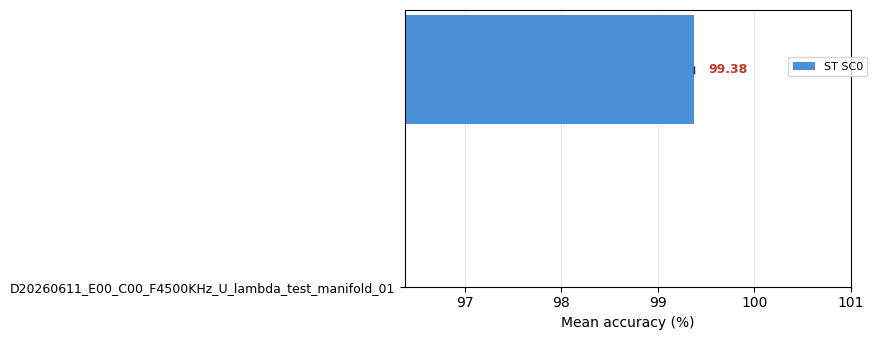

[!] No data found for the requested combination.


In [44]:
compared_families = ['MTL', 'LC_LABEL', 'CL','GRU_RCFD']
compared_sc = 2

plot_cross_dataset_family_comparison_h(
    baseline_family='ST',
    baseline_sc=0,
    # compared_families= ['MTL', 'LC_LABEL'],
    compared_families= compared_families,
    compared_sc=compared_sc,
    metric='accuracy',
)

plot_cross_dataset_family_comparison_h(
    baseline_family=compared_families[0],
    baseline_sc=0,
    compared_families= compared_families[1:],
    # compared_families= [],
    compared_sc=compared_sc,
    metric='rmse',
)

# # compared_families = ['CNN_RCFD', 'GRU_RCFD', 'TRANS_RCFD']
# # compared_families = ['LC', 'CL','GRU_RCFD']
# compared_scs = [compared_sc]

# for cf in compared_families:
#     for sc in compared_scs:    
#         plot_cross_dataset_family_comparison_h(
#             baseline_family='ST',
#             baseline_sc=0,
#             compared_families= [cf],
#             compared_sc=sc,
#             metric='accuracy',
#         )

#         plot_cross_dataset_family_comparison_h(
#             baseline_family=['MTL'],
#             baseline_sc=0,
#             compared_families= [cf],
#             compared_sc=sc,
#             metric='rmse',
#         )
#     print("="*100)

In [45]:
plot_cross_dataset_family_comparison_h(
    baseline_family='MTL',
    baseline_sc=2,
    compared_families= ['GRU_RCFD'],
    # compared_families= [],
    compared_sc=compared_sc,
    metric='rmse',
)

[!] No data found for the requested combination.


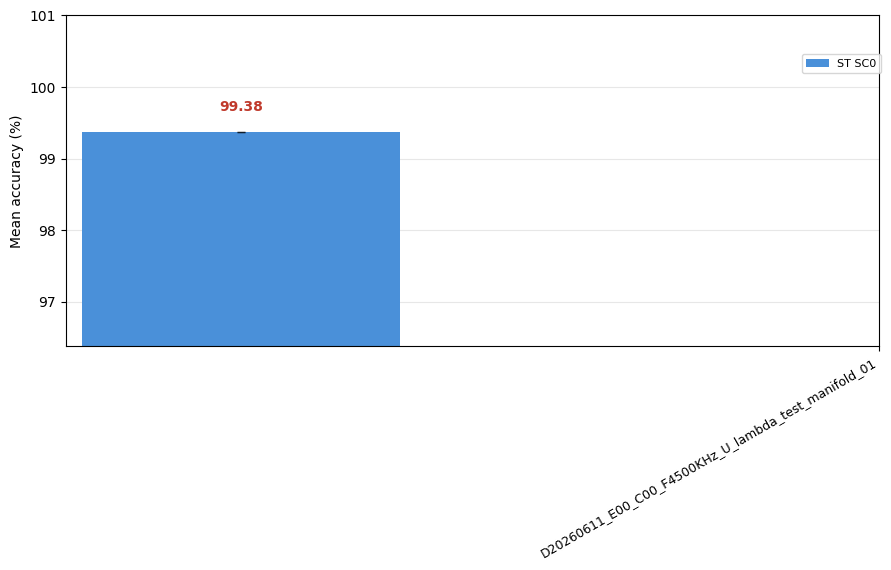

[!] No data found for the requested combination.


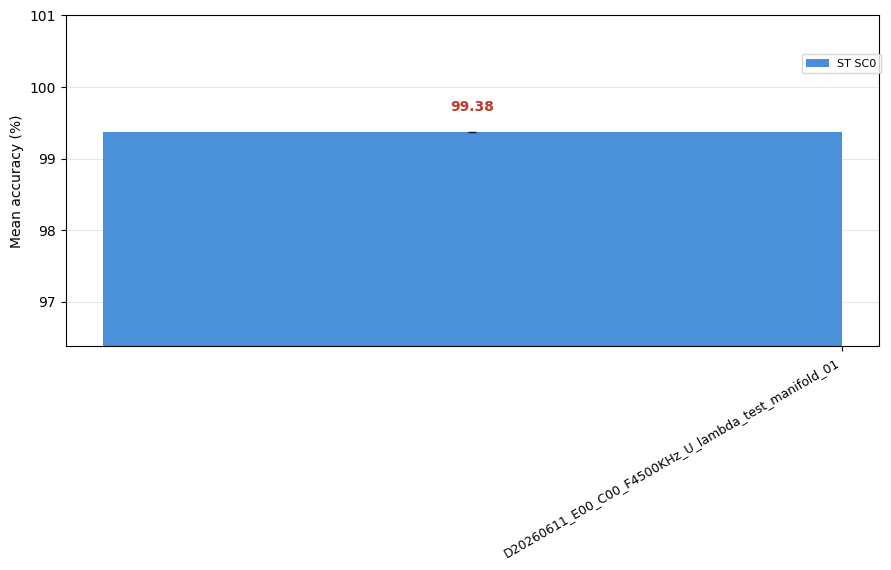

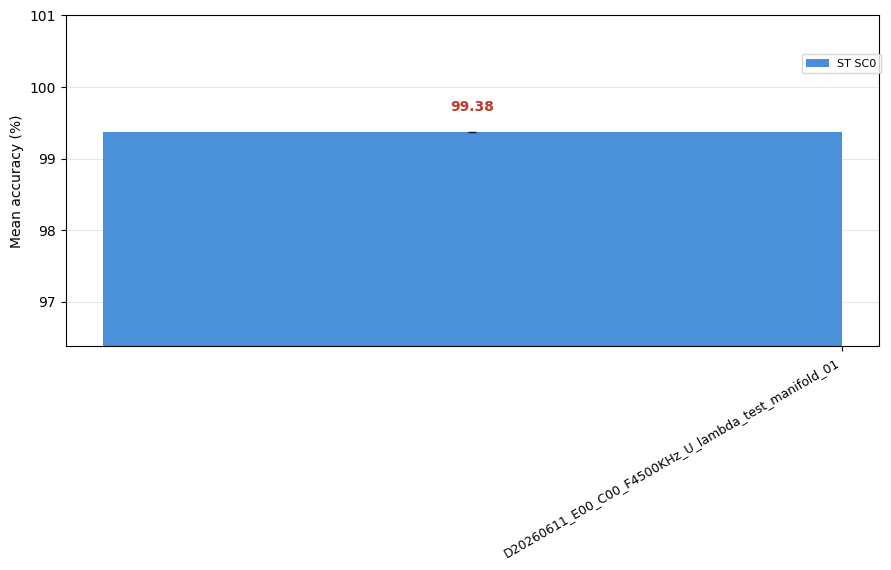

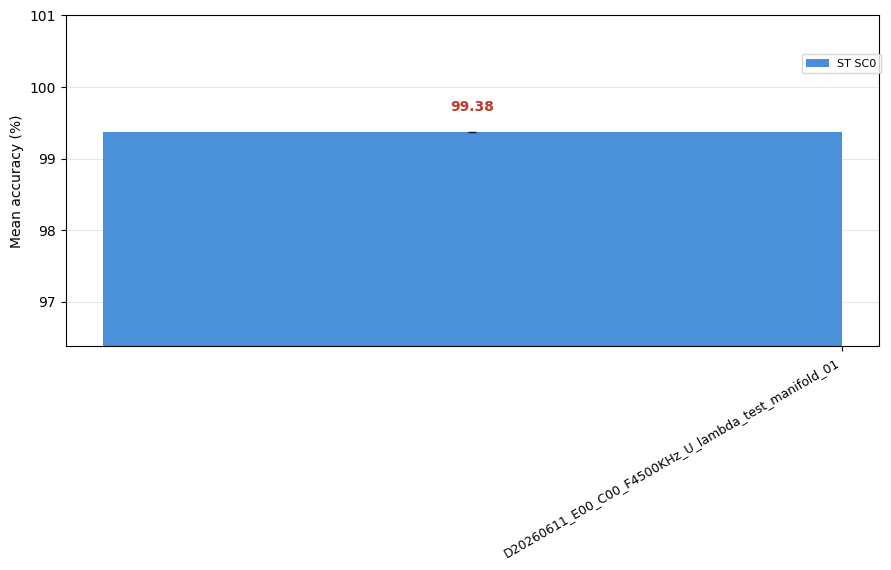

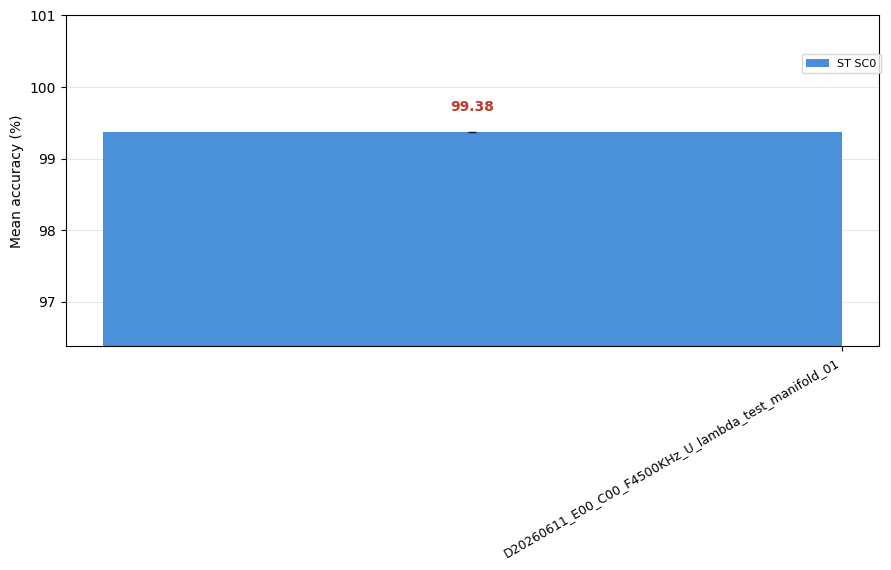

In [46]:
compared_families = ['MTL', 'LC_LABEL', 'CL','GRU_RCFD']
compared_sc = 2

plot_cross_dataset_family_comparison(
    baseline_family='ST',
    baseline_sc=0,
    # compared_families= ['MTL', 'LC_LABEL'],
    compared_families= compared_families,
    compared_sc=compared_sc,
    metric='accuracy',
)

plot_cross_dataset_family_comparison(
    baseline_family=compared_families[0],
    baseline_sc=0,
    compared_families= compared_families[1:],
    # compared_families= [],
    compared_sc=compared_sc,
    metric='rmse',
)

# compared_families = ['CNN_RCFD', 'GRU_RCFD', 'TRANS_RCFD']
# compared_families = ['LC', 'CL','GRU_RCFD']
compared_scs = [compared_sc]

for cf in compared_families:
    for sc in compared_scs:    
        plot_cross_dataset_family_comparison(
            baseline_family='ST',
            baseline_sc=0,
            compared_families= [cf],
            compared_sc=sc,
            metric='accuracy',
        )

        # plot_cross_dataset_family_comparison(
        #     baseline_family=['MTL'],
        #     baseline_sc=0,
        #     compared_families= [cf],
        #     compared_sc=sc,
        #     metric='rmse',
        # )
    print("="*100)

In [47]:
# -- RCFD FiLM weight visualization ------------------------------------------
# Reads film_gamma and film_beta Dense-layer weights from .keras zip archives
# without loading the full model (avoids Lambda-layer shape inference errors).
#
#   gamma-kernel L2 : L2 norm of film_gamma kernel -- multiplicative influence
#   beta-kernel  L2 : L2 norm of film_beta  kernel -- additive shift influence
#   gamma-bias dev  : mean|gamma_bias - 1| -- deviation from identity-init (ones)
#   beta-bias dev   : mean|beta_bias|      -- deviation from zero-init
#
# Parameters -- edit these, then re-run the cell
# -----------------------------------------------
_FILM_LAB_BASE     = LAB_FOLDER
_FILM_FOLDERS      = _folders
_FILM_CURVE_SUFFIX = 'ori_curve'
# -----------------------------------------------

import zipfile as _zipfile
import io      as _io_
import h5py    as _h5py_
import json    as _json_

_FILM_SC_SUFFIXES = {
    0: 'None',
    1: 'supcon_mtl_None',
    2: 'supcon2_mtl_None',
    3: 'supcon3_mtl_None',
}
_FILM_ENC_LABELS = {'cgd': 'CNN+GRU', 'ctd': 'CNN+Trans'}


def _film_dense_h5key(config_bytes):
    """Map Dense layer user name to its generic h5 key (dense, dense_1, ...)."""
    cfg = _json_.loads(config_bytes)
    layers = cfg.get('config', {}).get('layers', [])
    idx, mapping = 0, {}
    for l in layers:
        if l.get('class_name') == 'Dense':
            name = l.get('config', {}).get('name', '')
            mapping[name] = 'dense' if idx == 0 else f'dense_{idx}'
            idx += 1
    return mapping


def _extract_film_weights(keras_path):
    """Return (gamma_kernel, gamma_bias, beta_kernel, beta_bias) as numpy arrays."""
    with _zipfile.ZipFile(keras_path) as z:
        cfg_bytes = z.read('config.json')
        h5_bytes  = z.read('model.weights.h5')
    mapping = _film_dense_h5key(cfg_bytes)
    gk_key  = mapping.get('film_gamma')
    bk_key  = mapping.get('film_beta')
    if gk_key is None or bk_key is None:
        return None
    buf = _io_.BytesIO(h5_bytes)
    with _h5py_.File(buf, 'r') as h5:
        g_w = h5[f'layers/{gk_key}/vars/0'][:]
        g_b = h5[f'layers/{gk_key}/vars/1'][:]
        b_w = h5[f'layers/{bk_key}/vars/0'][:]
        b_b = h5[f'layers/{bk_key}/vars/1'][:]
    return g_w, g_b, b_w, b_b


def _film_model_path(lab_base, folder, enc, sc):
    sc_sfx = _FILM_SC_SUFFIXES[sc]
    fname  = f'cnn_rcfd_{enc}_{sc_sfx}_{_FILM_CURVE_SUFFIX}_model.keras'
    return Path(lab_base) / folder / 'model_interpretation' / fname


def plot_film_visualization(
    folders  = None,
    lab_base = _FILM_LAB_BASE,
    encs     = ('cgd', 'ctd'),
    scs      = (0, 1, 2, 3),
):
    if folders is None:
        folders = _FILM_FOLDERS

    # collect weights
    data = {}
    for folder in folders:
        for enc in encs:
            for sc in scs:
                p = _film_model_path(lab_base, folder, enc, sc)
                if not p.exists():
                    continue
                try:
                    res = _extract_film_weights(str(p))
                except Exception as e:
                    print(f'  [warn] {folder}/{enc}/SC{sc}: {e}')
                    continue
                if res is None:
                    continue
                gw, gb, bw, bb = res
                data.setdefault(folder, {}).setdefault(enc, {})[sc] = {
                    'gamma_k_l2':  float(np.linalg.norm(gw)),
                    'beta_k_l2':   float(np.linalg.norm(bw)),
                    'gamma_b_dev': float(np.mean(np.abs(gb - 1.0))),
                    'beta_b_dev':  float(np.mean(np.abs(bb))),
                }

    present_folders = [f for f in folders if f in data]
    if not present_folders:
        print('[!] No RCFD .keras files found for these folders.')
        return

    row_labels = [
        (folder, enc)
        for folder in present_folders
        for enc in encs
        if enc in data[folder]
    ]

    metrics_cfg = [
        ('gamma_k_l2',  'gamma-kernel L2\n(multiplicative)', 'Purples'),
        ('beta_k_l2',   'beta-kernel L2\n(additive shift)',  'Oranges'),
        ('gamma_b_dev', 'gamma-bias dev\n(from ones)',        'Blues'),
        ('beta_b_dev',  'beta-bias dev\n(from zeros)',        'Greens'),
    ]

    n_m = len(metrics_cfg)
    n_r = len(row_labels)
    fig, axes = plt.subplots(1, n_m, figsize=(n_m * 4.2, max(3.5, n_r * 0.6 + 1.8)))

    for ax, (mkey, mtitle, cmap_name) in zip(axes, metrics_cfg):
        mat = np.full((n_r, len(scs)), np.nan)
        for ri, (folder, enc) in enumerate(row_labels):
            for ci, sc in enumerate(scs):
                v = data.get(folder, {}).get(enc, {}).get(sc, {}).get(mkey)
                if v is not None:
                    mat[ri, ci] = v

        vmax = np.nanmax(mat) if not np.all(np.isnan(mat)) else 1.0
        im = ax.imshow(mat, aspect='auto', cmap=cmap_name, vmin=0, vmax=vmax)

        ax.set_xticks(range(len(scs)))
        ax.set_xticklabels([f'SC{s}' for s in scs], fontsize=9)
        ax.set_yticks(range(n_r))
        ax.set_yticklabels(
            [f'{f}\n{_FILM_ENC_LABELS.get(e, e)}' for f, e in row_labels],
            fontsize=7,
        )
        ax.set_title(mtitle, fontsize=9, fontweight='bold')

        for ri in range(n_r):
            for ci in range(len(scs)):
                v = mat[ri, ci]
                if not np.isnan(v):
                    txt_col = 'white' if v > vmax * 0.55 else '#333'
                    ax.text(ci, ri, f'{v:.3f}', ha='center', va='center',
                            fontsize=7, color=txt_col)

        plt.colorbar(im, ax=ax, shrink=0.65, pad=0.02)

    plt.suptitle('RCFD FiLM influence: concentration -> embedding modulation',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # text summary
    hdr = f"{'Dataset':<35} {'Enc':<10} {'SC':>3}  {'gk-L2':>8}  {'bk-L2':>8}  {'gb-dev':>8}  {'bb-dev':>8}"
    print(hdr)
    print('-' * len(hdr))
    for folder in present_folders:
        for enc in encs:
            if enc not in data[folder]:
                continue
            for sc in scs:
                row = data[folder][enc].get(sc)
                if row is None:
                    continue
                print(f"{folder:<35} {_FILM_ENC_LABELS.get(enc, enc):<10} {sc:>3}  "
                      f"{row['gamma_k_l2']:>8.4f}  {row['beta_k_l2']:>8.4f}  "
                      f"{row['gamma_b_dev']:>8.4f}  {row['beta_b_dev']:>8.4f}")




---

### gamma-kernel L2 — `‖W_γ‖₂`

How much the concentration value can **multiplicatively scale** each embedding dimension.

- `W_γ` shape `(1, 96)`: maps scalar concentration → 96 scale factors
- **Near zero**: gamma ≈ 1 everywhere → concentration does nothing to scaling
- **High (~3)**: concentration drives large per-dimension scale changes, some dimensions get amplified or suppressed depending on sample concentration

---

### beta-kernel L2 — `‖W_β‖₂`

How much concentration can **additively shift** the embedding.

- Same shape `(1, 96)`, same logic, but for the additive term
- Generally smaller than gamma-kernel L2 → concentration influences *gating* more than *shifting*
- **Near zero**: beta ≈ 0 → no additive concentration influence

---

### gamma-bias dev — `mean|b_γ − 1|`

Whether the **baseline scale** (independent of concentration) drifted from identity.

- `b_γ` initialised to **ones** so epoch-0 scale = 1 (embedding unchanged)
- **Near zero**: baseline is still "scale nothing"; concentration is the only reason gamma deviates from 1
- **Higher**: model also learned a static per-dimension scaling that applies regardless of concentration, the embedding representation itself shifted

---

### beta-bias dev — `mean|b_β|`

Whether the **baseline shift** (independent of concentration) drifted from zero.

- `b_β` initialised to **zeros** (no additive offset at epoch 0)
- **Near zero**: shifts are almost entirely driven by concentration
- **Higher**: model learned a static additive offset per embedding dimension, FiLM acting partly as a learned bias layer, not just concentration-conditioned

---

### Reading the numbers together

| Pattern | Meaning |
|---|---|
| gamma L2 >> beta L2 | Concentration mainly **gates** (which features matter) rather than shifts |
| Both L2 near zero | FiLM learned nothing — model ignores concentration entirely |
| Bias devs near zero | Behaviour is purely concentration-responsive, not static re-biasing |
| High bias devs | FiLM also acts as a learned static transformation on top of conditioning |

Observed values (gamma ~1.5–3.3, beta ~0.5–1.5, bias devs <0.25) indicate **meaningful concentration conditioning**, dominated by multiplicative gating, with modest static drift — consistent with FiLM doing its intended job.


In [48]:
plot_film_visualization()


[!] No RCFD .keras files found for these folders.


In [49]:
# ── Confusion matrix: CNN+GRU Dual  (true = class+conc, pred = class) ─────────

def _conc_label_cm(v):
    """Human-readable concentration value for CM y-axis labels."""
    v = float(v)
    if v <= 0:  return '0'
    if v >= 1e6: return f'{v/1e6:.3g}M'
    if v >= 1e3: return f'{v/1e3:.3g}K'
    return f'{v:.3g}'


def _load_label_map(folder):
    """Load real class labels from curve_for_training.joblib.

    Returns sorted list of unique Y_well values; index i -> label string.
    Falls back to None if file not found.
    """
    p = LAB_FOLDER / folder / 'curve_for_training.joblib'
    if not p.exists():
        return None
    d = joblib.load(str(p))
    labels = d.get('Y_well')
    if labels is None:
        return None
    return sorted(np.unique(labels))


def _get_reg_trues_cm(res, key):
    """Return per-fold concentration arrays: key's own first, then any available."""
    k = f'y_reg_trues_{key}_'
    if k in res:
        return res[k]
    for rk in res:
        if rk.startswith('y_reg_trues_'):
            return res[rk]
    return None


def _extract_classes_flat(res_entry, clsk):
    """Return 1-D class-label array regardless of fold-storage format.

    Old format: stored as list-of-1-fold -> np.asarray gives (1, n_cls).
    New format: stored as list-of-n_folds -> np.asarray gives (n_folds, n_cls).
    Both: take first list element to get the flat (n_cls,) array.
    """
    raw = res_entry.get(clsk)
    if raw is None:
        return np.array([])
    if isinstance(raw, list):
        return np.asarray(raw[0]) if raw else np.array([])
    arr = np.asarray(raw)
    return arr[0] if arr.ndim > 1 else arr


def plot_confusion_gru(res_entry, folder, family, mode='normalized'):
    """2x2 confusion matrix grid: CNN+GRU Dual x SC0/SC1/SC2/SC3.

    True  y-axis : 'ClassName  concLabel'  e.g. 'KPC  1M'
    Pred  x-axis : class label only

    Parameters
    ----------
    res_entry : dict    result dict for one folder / outlier-filter
    folder    : str     dataset name / folder key (used to load real class labels)
    family    : str     'ST' | 'MTL' | 'CL' | 'CNN RCFD' | 'GRU RCFD' | 'Trans RCFD'
    mode      : 'count' | 'normalized'  (row-wise normalisation to sum 1)
    """
    _fam_map = {fl: ft for fl, ft in _FAMILIES}
    fam_tag  = _fam_map.get(family)
    if fam_tag is None:
        print(f'[!] Unknown family {family!r}. Options: {list(_fam_map)}')
        return

    _REG_SENTINEL = -1.0

    # Real class label strings (sorted, index i -> label)
    label_map = _load_label_map(folder)   # list or None

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes_flat  = axes.flatten()
    _sc_accs = {}  # si -> accuracy (nan for no-data subplots)

    for si, sc in enumerate([0, 1, 2, 3]):
        ax  = axes_flat[si]
        key = _combo_key(fam_tag, sc, 'cnn_gru_dual')
        ax.set_title(f'SC {sc}', fontsize=11, fontweight='bold', pad=6)  # placeholder

        if key is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=13, color='#bbb')
            ax.axis('off')
            continue

        _lc_label_only = key is not None and key.endswith('__lo')
        _real_key = key[:-4] if _lc_label_only else key
        _is_lc_key = _real_key is not None and _real_key.endswith('_lc')
        _map = config.MODEL_KEY_MAP.get(_real_key if _lc_label_only else key)
        pk   = _map[0] if _map else f'y_preds_AC_{_real_key if _lc_label_only else key}_'
        clsk = _map[2] if _map else f'classes_AC_{_real_key if _lc_label_only else key}_'

        classes_flat = _extract_classes_flat(res_entry, clsk)

        if pk not in res_entry or 'y_trues_' not in res_entry:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='#bbb')
            ax.axis('off')
            continue

        # LC keys: classes_AC_* has combined strings (e.g. KPC_1M) — use them, not Y_well.
        if _is_lc_key:
            if len(classes_flat) > 0 and classes_flat.dtype.kind in ('U', 'S', 'O'):
                cls_names = list(classes_flat)
            else:
                cls_names = _load_lc_classes(folder) or []
        elif label_map is not None:
            cls_names = label_map
        elif len(classes_flat) > 0 and classes_flat.dtype.kind in ('U', 'S', 'O'):
            cls_names = list(classes_flat)
        else:
            cls_names = [str(c) for c in classes_flat] if len(classes_flat) > 0 else []

        def _cls_label(idx):
            i = int(idx)
            if 0 <= i < len(cls_names):
                return cls_names[i]
            return str(i)

        conc_folds = _get_reg_trues_cm(res_entry, _real_key if _lc_label_only else key)

        all_y_true = np.concatenate([np.asarray(f) for f in res_entry['y_trues_']])
        all_y_pred = np.concatenate([np.asarray(f) for f in res_entry[pk]])
        if conc_folds is not None:
            all_conc = np.concatenate([np.asarray(f, dtype=float) for f in conc_folds])
        else:
            all_conc = np.full(len(all_y_true), np.nan)

        # Build per-sample (label_str, class_idx, conc_float) for sorting
        tl_info = []
        for c, v in zip(all_y_true, all_conc):
            ci  = int(c)
            cn  = _cls_label(ci)
            nan = np.isnan(v) or v == _REG_SENTINEL
            lbl = f'{cn}  {_conc_label_cm(v)}' if not nan else cn
            tl_info.append((lbl, ci, float('inf') if nan else float(v)))

        tl_list = [x[0] for x in tl_info]
        pl_list = [_cls_label(p) for p in all_y_pred]

        # For LC label-only variant: remap both axes to base-label strings
        if _lc_label_only and cls_names:
            _stripped = [c.rsplit('_', 1)[0] for c in cls_names]
            tl_list = [_stripped[int(c)] for c in all_y_true]
            pl_list = [_stripped[int(p)] for p in all_y_pred]

        # Unique true-label strings ordered by (class_idx, concentration asc)
        if _lc_label_only and cls_names:
            _stripped = [c.rsplit('_', 1)[0] for c in cls_names]
            unique_true = sorted(set(_stripped))
            unique_pred = unique_true
        else:
            seen = {}
            for lbl, ci, cv in tl_info:
                if lbl not in seen:
                    seen[lbl] = (ci, cv)
            unique_true = sorted(seen, key=lambda l: (seen[l][0], seen[l][1]))
            unique_pred = cls_names if cls_names else sorted(set(pl_list))

        t2i = {t: i for i, t in enumerate(unique_true)}
        p2j = {p: j for j, p in enumerate(unique_pred)}
        mat = np.zeros((len(unique_true), len(unique_pred)), dtype=int)
        for t, p in zip(tl_list, pl_list):
            if t in t2i and p in p2j:
                mat[t2i[t], p2j[p]] += 1

        # Correct accuracy for non-square matrix (true=class+conc rows, pred=class cols)
        _total = mat.sum()
        _correct = sum(
            mat[ri, p2j[lbl.split('  ')[0] if '  ' in lbl else lbl]]
            for ri, lbl in enumerate(unique_true)
            if (lbl.split('  ')[0] if '  ' in lbl else lbl) in p2j
        )
        acc = (_correct / _total * 100) if _total > 0 else float('nan')
        _sc_accs[si] = acc
        ax.set_title(f'SC {sc}  ({acc:.2f}%)', fontsize=11, fontweight='bold', pad=6)

        if mode == 'normalized':
            row_sums = mat.sum(axis=1, keepdims=True)
            disp     = np.divide(mat.astype(float), row_sums,
                                 where=row_sums > 0, out=np.zeros_like(mat, float))
            fmt, cb_l, vmax_arg = '.2f', 'Proportion', 1.0
        else:
            disp     = mat           # keep as int to avoid float format errors
            fmt, cb_l, vmax_arg = 'd', 'Count', None

        im = ax.imshow(disp.astype(float), cmap='Blues', aspect='auto',
                       vmin=0, vmax=vmax_arg)
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label=cb_l)

        ax.set_xticks(range(len(unique_pred)))
        ax.set_xticklabels(unique_pred, rotation=30, ha='right', fontsize=8.5)
        ax.set_yticks(range(len(unique_true)))
        ax.set_yticklabels(unique_true, fontsize=8)
        ax.set_xlabel('Predicted', fontsize=9)
        _ylabel = 'True  (base label)' if _lc_label_only else 'True  (class + concentration)'
        ax.set_ylabel(_ylabel, fontsize=9)

        thresh = disp.astype(float).max() / 2.0
        for ri in range(len(unique_true)):
            for ci in range(len(unique_pred)):
                v = disp[ri, ci]
                ax.text(ci, ri, format(v, fmt),
                        ha='center', va='center', fontsize=8,
                        color='white' if v > thresh else '#222')

    # Star on best-accuracy SC
    valid = {si: acc for si, acc in _sc_accs.items() if not np.isnan(acc)}
    if valid:
        best_si = max(valid, key=valid.get)
        best_ax = axes_flat[best_si]
        best_ax.set_title('★ ' + best_ax.get_title(),
                          fontsize=11, fontweight='bold', pad=6, color='#c8860a')

    fig.suptitle(
        f'Confusion Matrix  --  {folder}  --  {family}\n(CNN+GRU Dual)',
        fontsize=12, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()


In [50]:
# print(list_available_folders().to_string(index=False))

#                      folder  n_samples  n_targets  n_conc conc_range
#                01_ACA_qdPCR      16188          3       6    5K – 1M
#              02_AMCA_qdLAMP      54186          5       7   2K – 10M
#               03_AMCA_qdPCR      58598          9       5   1K – 10M
#  07_ACA_qdPCR_conc_filtered      15146          3       4   50K – 1M
# 08_AMCA_qdPCR_conc_filtered      53793          9       3 100K – 10M
#                09_Area_Conc      34650          5       3   10K – 1M
#               10_Range_Conc      23100          5       3   10K – 1M

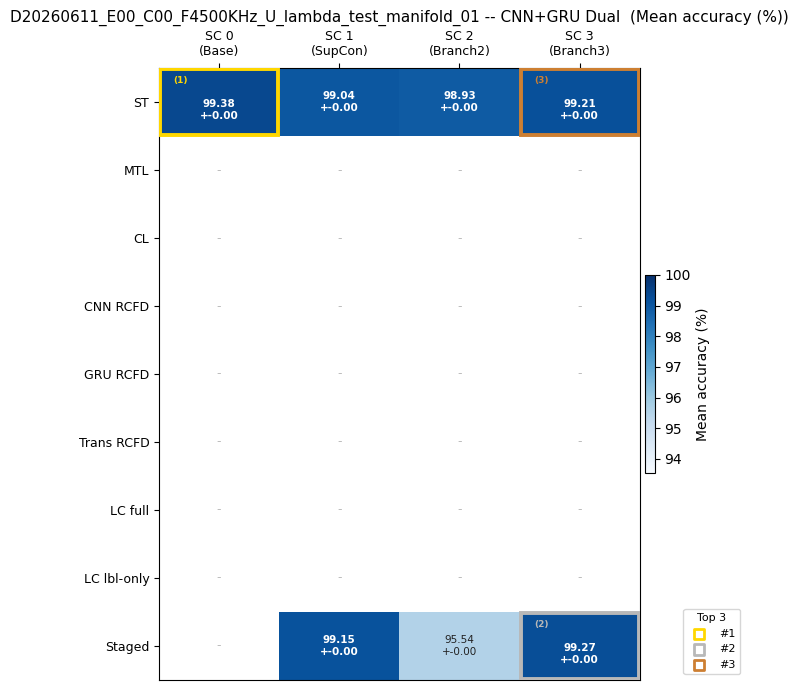

In [51]:
_folders = ['D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01']
# _folders = ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR']

for _folder in _folders:
    _raw = load_results(_folder)
    if _raw is None:
        continue
    _res, _, _ = _get_res_entry(_raw, OUTLIER_FILTER)
    if _res is None:
        print(f'[!] {_folder}: no entry for filter={OUTLIER_FILTER!r}. Skipping.')
        continue
    # print(f'\n{"─"*150}')
    # print(f'\n{"─"*150}')
    # print(f'\n{"─"*150}\n{_folder}')
    # ── Classification metrics ─────────────────────────────────────────────
    # plot_all_combinations(_res, _folder, metric='accuracy') ############
    # # plot_all_combinations(_res, _folder, metric='sensitivity')
    # # plot_all_combinations(_res, _folder, metric='specificity')
    # # plot_all_combinations(_res, _folder, metric='ppv')
    # # plot_all_combinations(_res, _folder, metric='npv')
    # # plot_all_combinations(_res, _folder, metric='f1')
    # # plot_all_combinations(_res, _folder, metric='roc_auc')
    # # ── Regression metrics (MTL / RCFD only) ──────────────────────────────
    # plot_all_combinations(_res, _folder, metric='rmse') #############
    # plot_all_combinations(_res, _folder, metric='mae')
    # plot_all_combinations(_res, _folder, metric='r2')
#     plot_rcfd_overview(_res, _folder)
#     plot_rcfd_vs_baseline(_res, _folder)
#     plot_rcfd_reg_comparison(_res, _folder)
    plot_all_combinations_gru(_res, _folder, metric='accuracy')
    # plot_all_combinations_gru(_res, _folder, metric='rmse')
    
# print('\n── Cross-dataset ──')
# for _dual in _RCFD_DUALS:
#     plot_rcfd_across_folders(_folders, dual=_dual, outlier_filter=OUTLIER_FILTER)    plot_all_combinations_gru(_res, _folder, metric='accuracy')
    


In [53]:
# _folder = _folders[0]
# for _folder in _folders:
#     _raw = load_results(_folder)
#     if _raw is None:
#         continue
#     _res, _, _ = _get_res_entry(_raw, OUTLIER_FILTER)
#     plot_confusion_gru(_res, _folder, family='ST')
#     plot_confusion_gru(_res, _folder, family='MTL')